In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [8]:
import os
print("current folder:", os.getcwd())
print("files in this folder:", os.listdir())

current folder: c:\Users\osfra\OneDrive\Desktop\marketing analysis
files in this folder: ['.git', 'marketing_analysis.ipynb']


In [11]:
df =pd.read_csv(r"c:\Users\osfra\OneDrive\Desktop\marketing_ROI_Analysis.csv")
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [12]:
df.shape

(4572, 4)

In [13]:
df.columns

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [15]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [16]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

# EPLORATORY DATA ANALYSIS EDA \
DISTRIBUTION OF SALES 

Text(0.5, 1.0, 'Distribution of Sales')

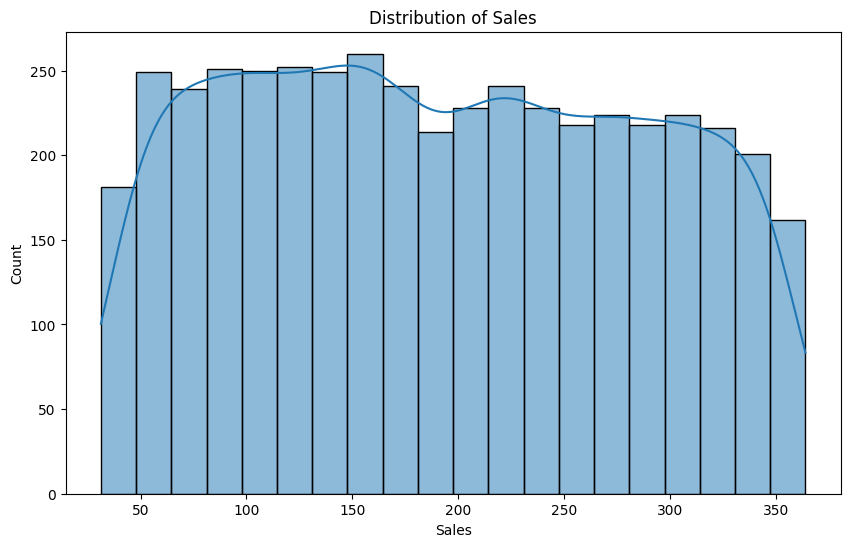

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title('Distribution of Sales')

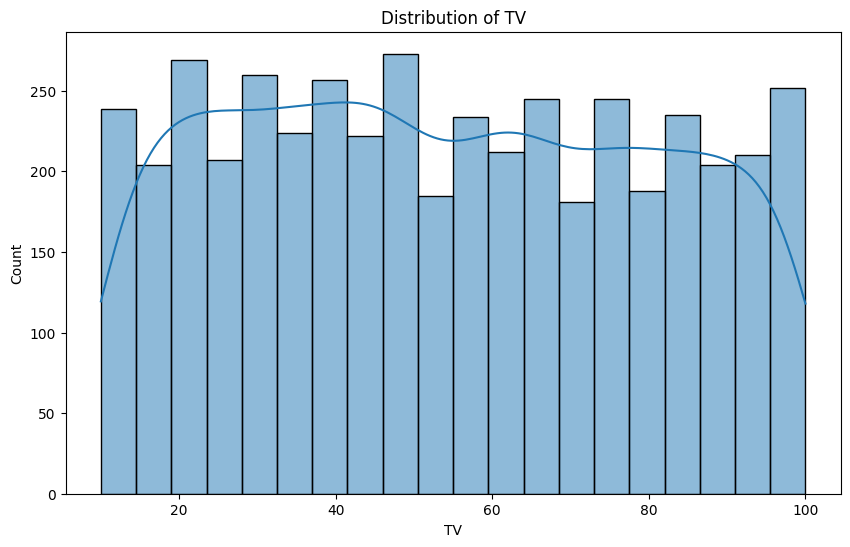

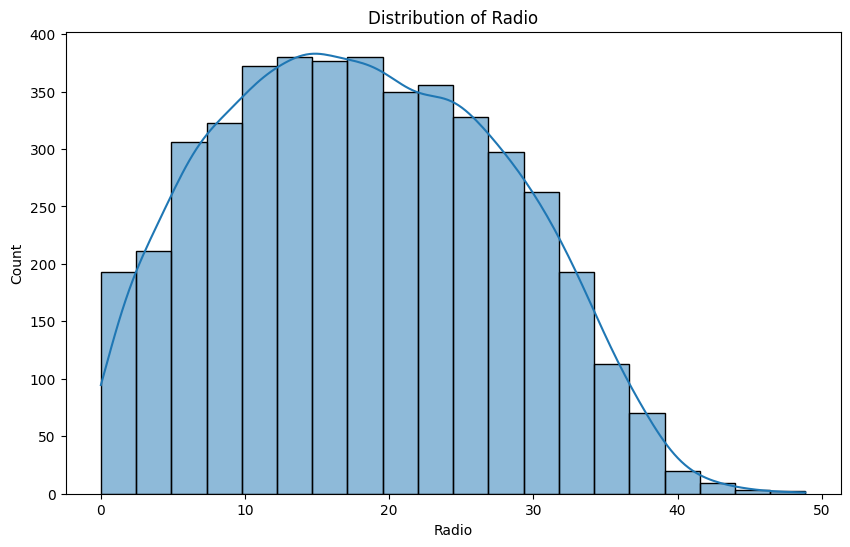

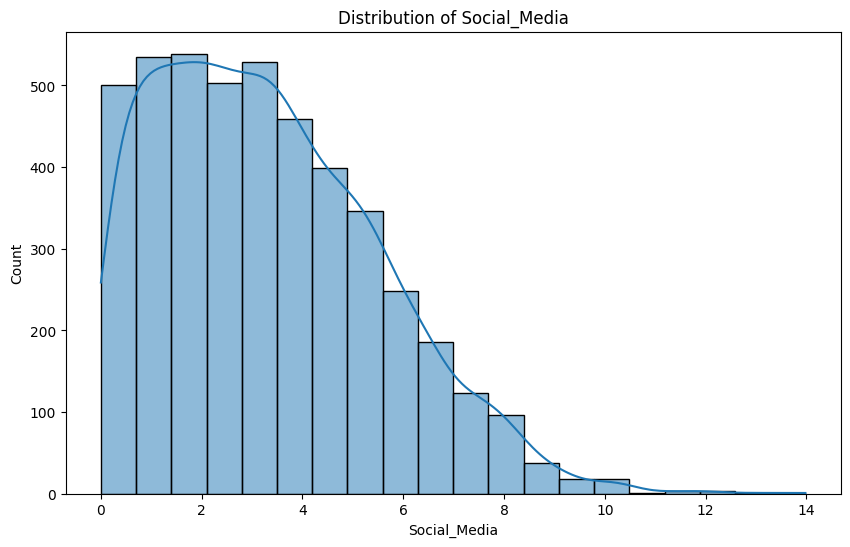

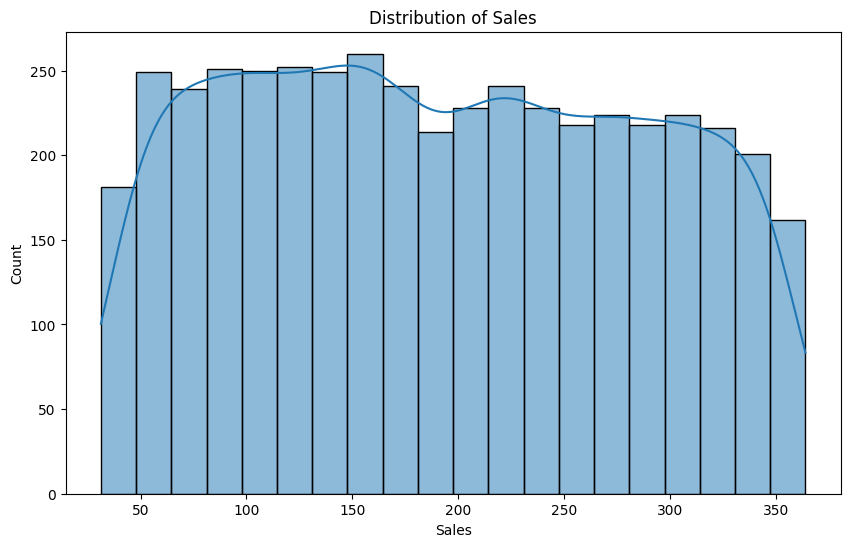

In [22]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Relationship between variables 

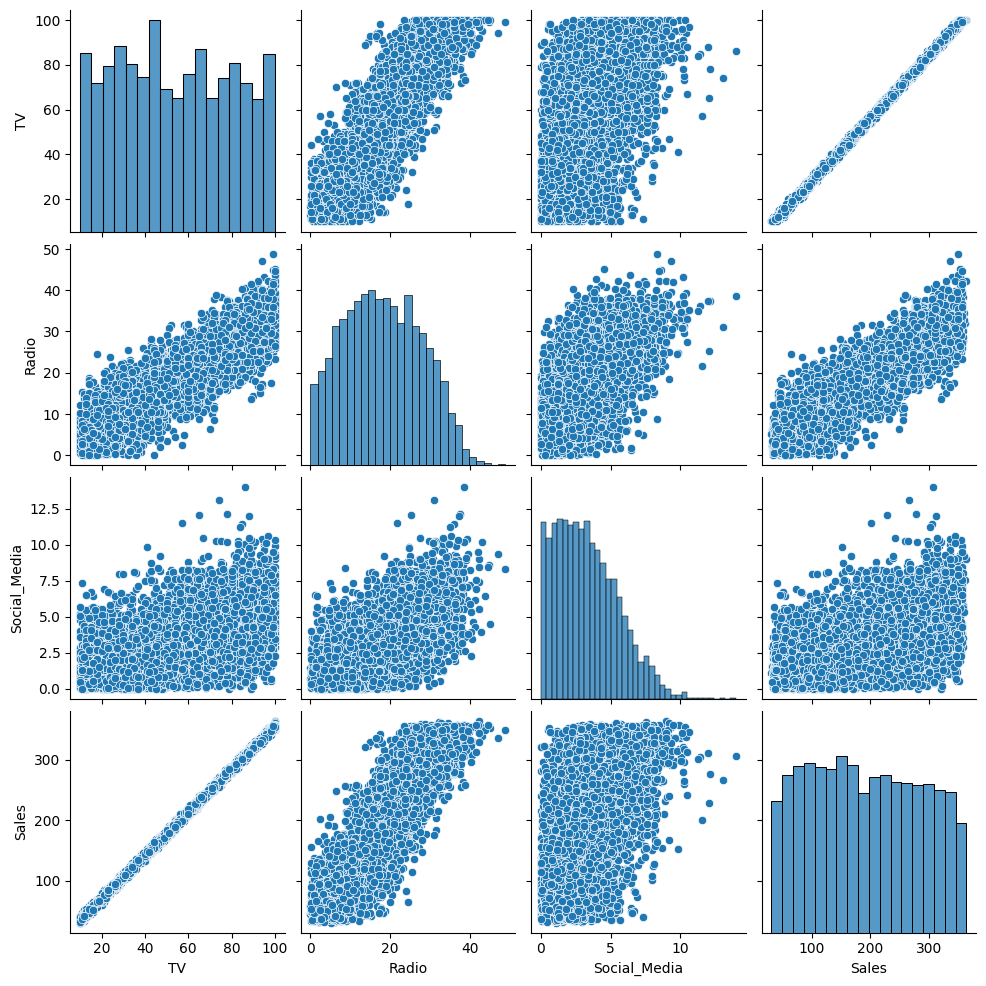

In [23]:
sns.pairplot(df)
plt.show()

# CORRELATION ANALYSIS 

In [24]:
corr = df.corr(numeric_only=True)

# SHOW HEATMAP

Text(0.5, 1.0, 'Correlation Matrix')

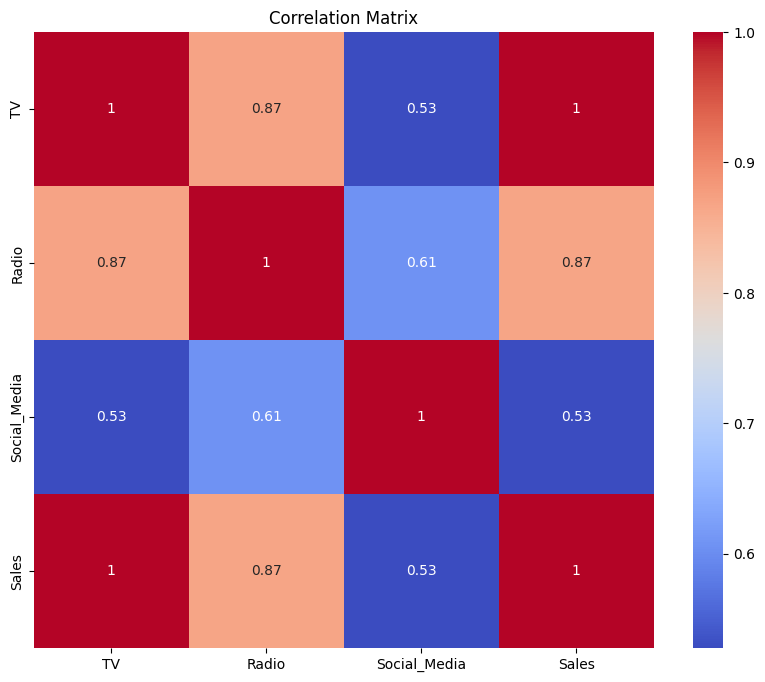

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

# check correlation with sales 

In [28]:
corr['Sales'].sort_values(ascending=False)

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64

# SINCE TV HAS THE HIGHEST SALES SO IT IS THE INDEPENDENT VARIABLE 

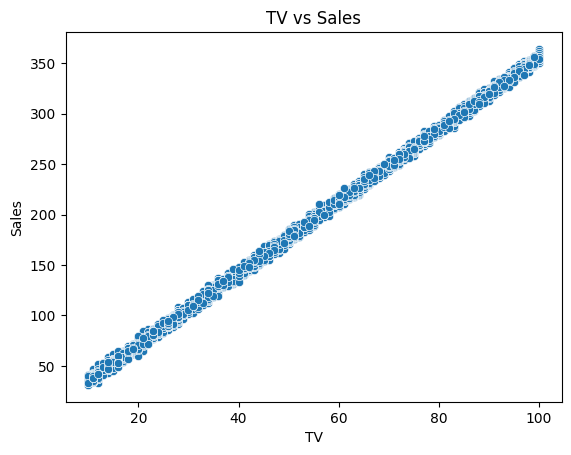

In [29]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV vs Sales')
plt.show()

# Building a regreesion model by defining X and Y

In [30]:
x = df[['TV']]
y = df[['Sales']]

# ADD A CONSTANT 

In [31]:
x = sm.add_constant(x)

# FIT MODEL

In [33]:
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:53:44   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

# From the OLS regression performed to examine how TV advertising budget affects sales, 
the dependent variable = sales 
independent variable = Tv adveetising spending
number of observations 4,546
key finding
1. # MODEL PERFORMANCE 
R- squared = 0.999: This means 99.9% of the variation in sales is explained by Tv advert spending which is almost a perfect fit model
2. # TV Advertising Coeficient
coefficent = 3.5615 (p-value <0.001)
for every $1 increase in TV advertising budget, sales increased by approximately $3.56 on average. This relationship is highly highly significant and statistical
3. # INTERCEPT
0.1325(not statistically significant)
when TV advert spend is zero, predicted sales are close to zero
4. # OVERALL MODEL SIGNIFICANCE
F- statistic is extremely high with p-value 0.000
the model as a whole is highly significant.
# IN SUMMARY
The OLS refression result as a whole, demonstrate that Tv advertising is powerful driver sales. With an R- squared of 0.999, the model shows that TV spend explains nearly all variations in sales. The coefficient of 3.5616 indicates a strong positive relationship suggesting that increasing TV budget is likely ti generate substential returns. This finding supports allocating more marketing resources towards TV advertising. 

# PREDICTED VALUES 

In [37]:
df['predicted_Sales'] = model.predict(x)
df[['Sales', 'predicted_Sales']].head()

,Sales,predicted_Sales
0,54.732757,56.851733
1,46.677897,46.167191
2,150.177829,145.889585
3,298.246340,295.473177
4,56.594181,53.290219


# REGRESSION LINE PLOT

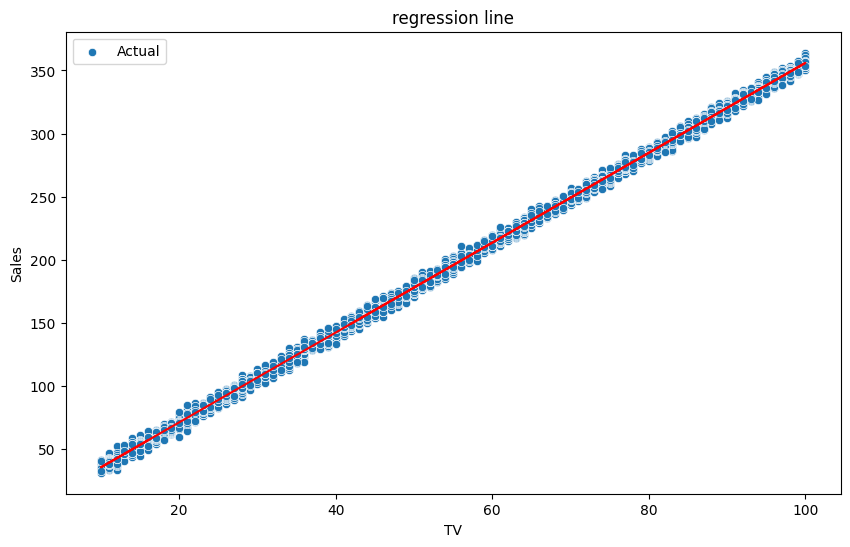

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['TV'], y=df['Sales'], data=df, label='Actual')
plt.plot(df['TV'], df['predicted_Sales'], color='red', label='Predicted')
plt.title("regression line")
plt.show()

# DIAGNOSTIC PLOT LINEARITY

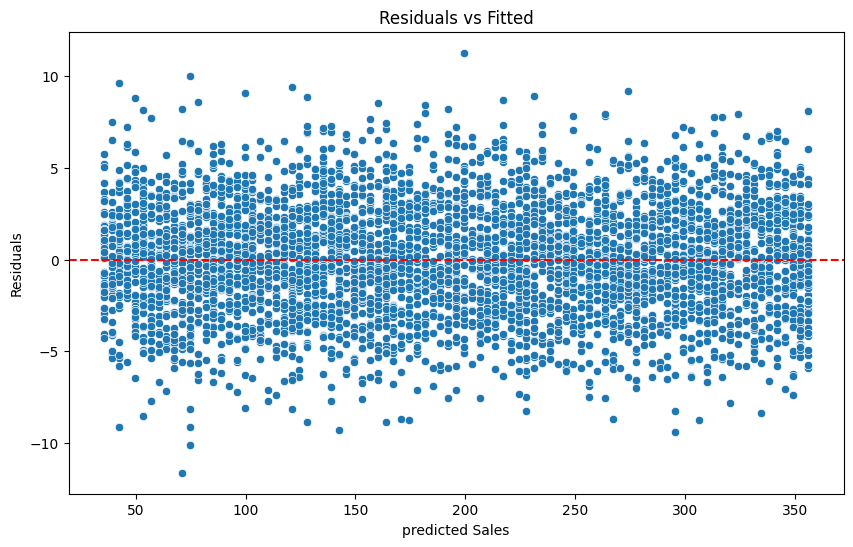

In [42]:
residuals = model.resid
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['predicted_Sales'], y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted')
plt.xlabel('predicted Sales')
plt.ylabel('Residuals')
plt.show()
    

# DIAGNOSTIC PLOT NORNALITY 

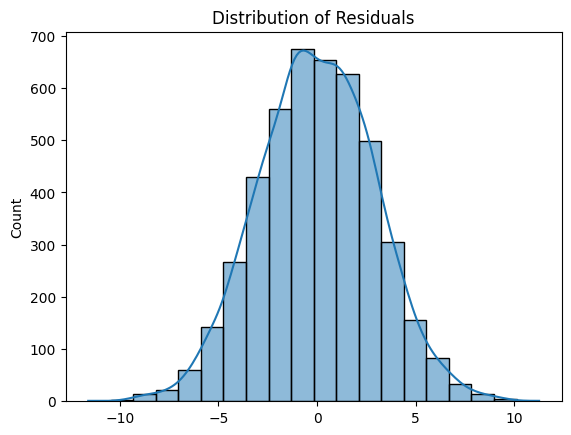

In [43]:
sns.histplot(residuals, bins=20, kde=True)
plt.title('Distribution of Residuals')
plt.show()

# Residuals approximatelt follows a normal distribution 

# DIAGNOSTIC PLOT- HOMOSCEDASTICY

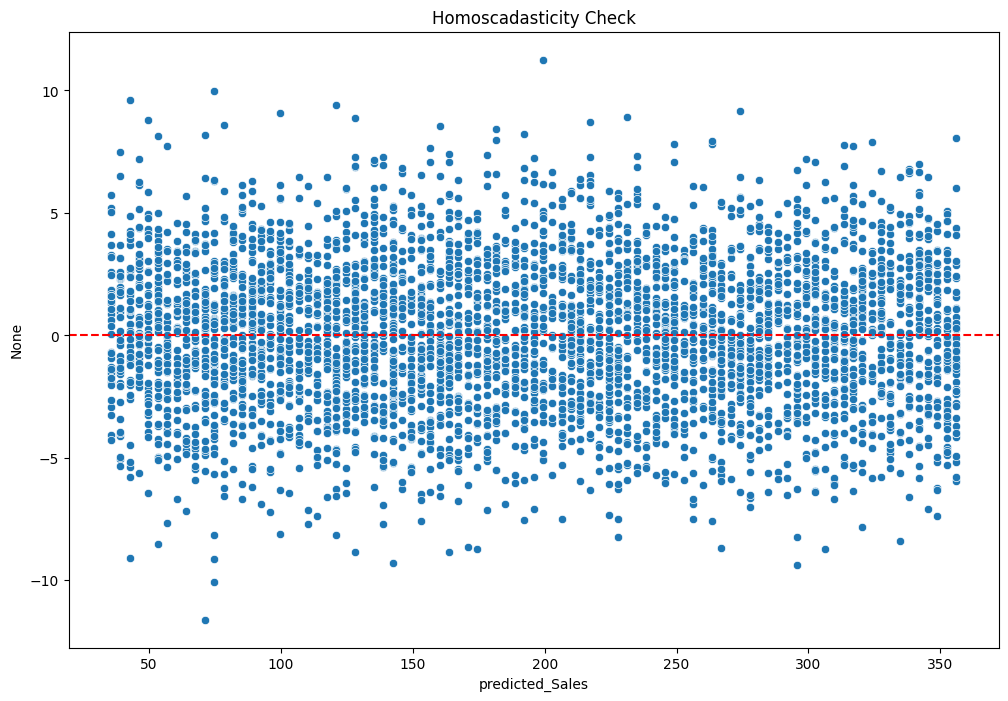

In [44]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df['predicted_Sales'], y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Homoscadasticity Check")
plt.show()

# BUSINESS INTERPRETATION 
The regression analysis shows that Tv advertising has the strongest relationship with sales. The model acheived an R-squared of 0.99, indication that 99% of sales variation is explained by TV advert expenditure. 
The coefficient fot TV advert is positive and statistically significant suggesting that the increased TV advert spending leads to higher sale. 
Diagnostic plots indicate that the assumption of linear regression are reasonably satisfied.
   # ROI RECOMMENDATION
Based on the correlation analysis and regression results, TV advertising should receive the highest marketing budget allocation. 
TV has the strongest positive relationship with sales and provides the most reliable prediction of revenue growth. 
Therefore, management should priotize investment in TV campaigns to maximize marketing ROI. 